# 🌸 Iris Flower Classification Using Machine Learning

## Project Overview

This project demonstrates the implementation of a supervised machine learning classification model using the Iris dataset.

The objective is to train an AI model capable of identifying iris flower species based on sepal and petal measurements.

### Technologies Used
- Python
- Google Colab
- Pandas
- Scikit-Learn
- Matplotlib

### Machine Learning Algorithm
- Decision Tree Classifier

# Import Libraries

In [15]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# 📊 Dataset Exploration

Before training the model, it is important to understand the dataset structure, available features, and target classes.

The Iris dataset contains 150 flower samples belonging to three different species:

1. Setosa
2. Versicolor
3. Virginica

Each sample contains four numerical features:
- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

# Load Dataset

In [16]:
iris = load_iris()

print("Features:")
print(iris.feature_names)

print("\nClasses:")
print(iris.target_names)

Features:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Classes:
['setosa' 'versicolor' 'virginica']


 # 🔍 Dataset Preview

Let's examine the first few records to understand the feature values available for model training.

In [17]:
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["Species"] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


# 📈 Data Visualization

Data visualization helps identify patterns, distributions, and relationships among features before training a machine learning model.

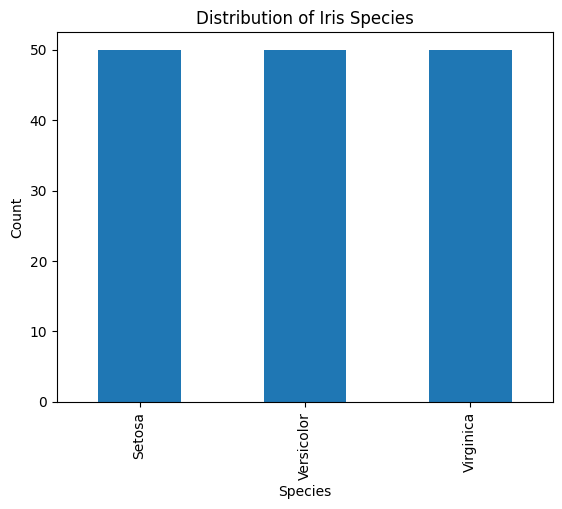

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["Species"] = iris.target
df["Species"] = df["Species"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

df["Species"].value_counts().plot(kind="bar")

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()

### Observation

The dataset is perfectly balanced, containing 50 samples from each species.

Balanced datasets generally help machine learning models learn without bias toward a particular class.

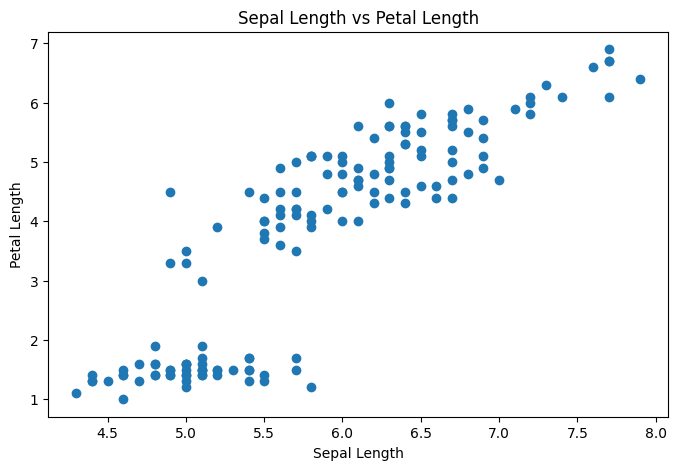

In [5]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["sepal length (cm)"],
    df["petal length (cm)"]
)

plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.title("Sepal Length vs Petal Length")

plt.show()

### Observation

The scatter plot reveals a clear separation between species based on petal and sepal measurements.

This indicates that classification algorithms should perform well on this dataset.

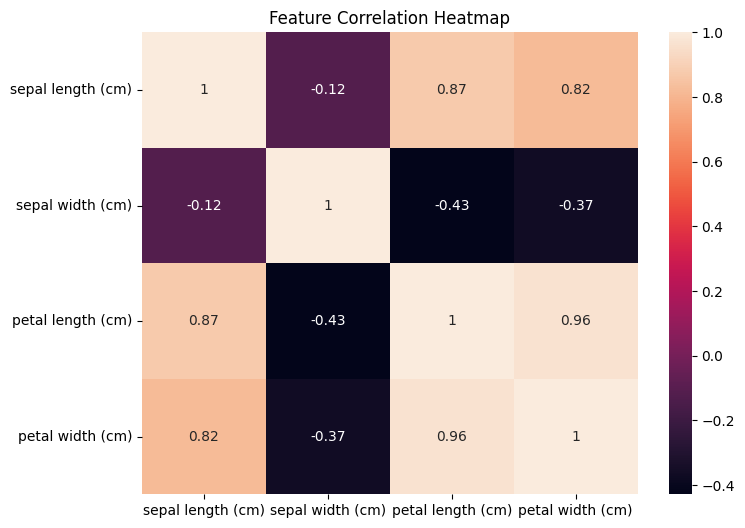

In [6]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    pd.DataFrame(
        iris.data,
        columns=iris.feature_names
    ).corr(),
    annot=True
)

plt.title("Feature Correlation Heatmap")

plt.show()

# 🤖 Model Training

The dataset is divided into training and testing subsets.

- Training Data: 80%
- Testing Data: 20%

The model learns from the training data and is evaluated on unseen testing data.

In [7]:
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 120
Testing Samples: 30


In [8]:
model = DecisionTreeClassifier()

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [9]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred[:10])

Predictions:
[1 0 2 1 1 0 1 2 1 1]


# 📋 Model Evaluation

After training, the model is tested on unseen data to measure its predictive performance.

In [10]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 100.0 %


In [11]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# ⚖️ Algorithm Comparison

To improve reliability, a second classification algorithm (K-Nearest Neighbors) is trained and compared against the Decision Tree model.

In [12]:
from sklearn.neighbors import KNeighborsClassifier

dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)

dt_accuracy = accuracy_score(
    y_test,
    dt_model.predict(X_test)
)

knn_accuracy = accuracy_score(
    y_test,
    knn_model.predict(X_test)
)

print(dt_accuracy)
print(knn_accuracy)

1.0
1.0


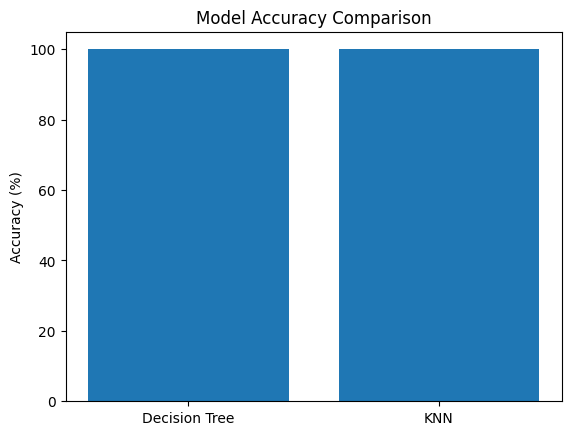

In [13]:
models = ["Decision Tree", "KNN"]
accuracies = [
    dt_accuracy * 100,
    knn_accuracy * 100
]

plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")

plt.show()

# 🔮 Real-Time Prediction

The trained model can classify a new flower sample based on its measurements.

In [14]:
sample_flower = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(sample_flower)

print(
    "Predicted Species:",
    iris.target_names[prediction[0]]
)

Predicted Species: setosa


# ✅ Conclusion

This project successfully demonstrated the complete supervised machine learning workflow:

- Data Loading
- Data Exploration
- Data Visualization
- Model Training
- Model Evaluation
- Model Comparison
- Real-Time Prediction

The Decision Tree and KNN models achieved high accuracy, proving that machine learning can effectively classify Iris flower species based on their physical characteristics.